<a href="https://colab.research.google.com/github/tanishataranoon/MY_ML_project/blob/main/Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Toxic Comment Classification:
# A Comparative Study of ML, DL, and Transformer Models

# Course: CSE 414 - ML & DL Lab


# 1. Install & import

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud transformers torch --quiet

In [2]:
# Core
import numpy as np
import pandas as pd
import re
import time
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import *

# DL
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

# Transformer
import torch
from transformers import *

sns.set_theme(style='whitegrid')

# 2. Dataset Loading

from https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge?library=datasets


## 2.1 Load dataset


In [3]:
from datasets import load_dataset

df = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

test_labels.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

## 2.2 Basic inspection

In [4]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

In [5]:
train_df = df['train'].to_pandas()
test_df = df['test'].to_pandas()
print(train_df.shape)
print(test_df.shape)

(159571, 8)
(306328, 8)


## 2.3 Label setup & Toxic distribution

In [6]:
print('Columns: ', train_df.columns.tolist())

Columns:  ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [7]:
print('\nData Types: \n', train_df.dtypes)


Data Types: 
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


In [8]:
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_df['any_toxic'] = train_df[label_cols].max(axis=1)


print(f'Total comments    : {len(train_df):,}')
print(f'Toxic comments    : {train_df["any_toxic"].sum():,} ({train_df["any_toxic"].mean()*100:.1f}%)')
print(f'Non-toxic comments: {(train_df["any_toxic"]==0).sum():,} ({(train_df["any_toxic"]==0).mean()*100:.1f}%)')

Total comments    : 159,571
Toxic comments    : 16,225 (10.2%)
Non-toxic comments: 143,346 (89.8%)


# 3 . Exploratory Data Analysis (EDA)


## 3.1 Label distribution

In [9]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


In [10]:
co_matrix = train_df[label_cols].T.dot(train_df[label_cols])
co_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


## 3.2 Toxic vs non-toxic

Bar Chart of Number of Comments per Toxicity Label
A pie chart for non-toxic vs toxic

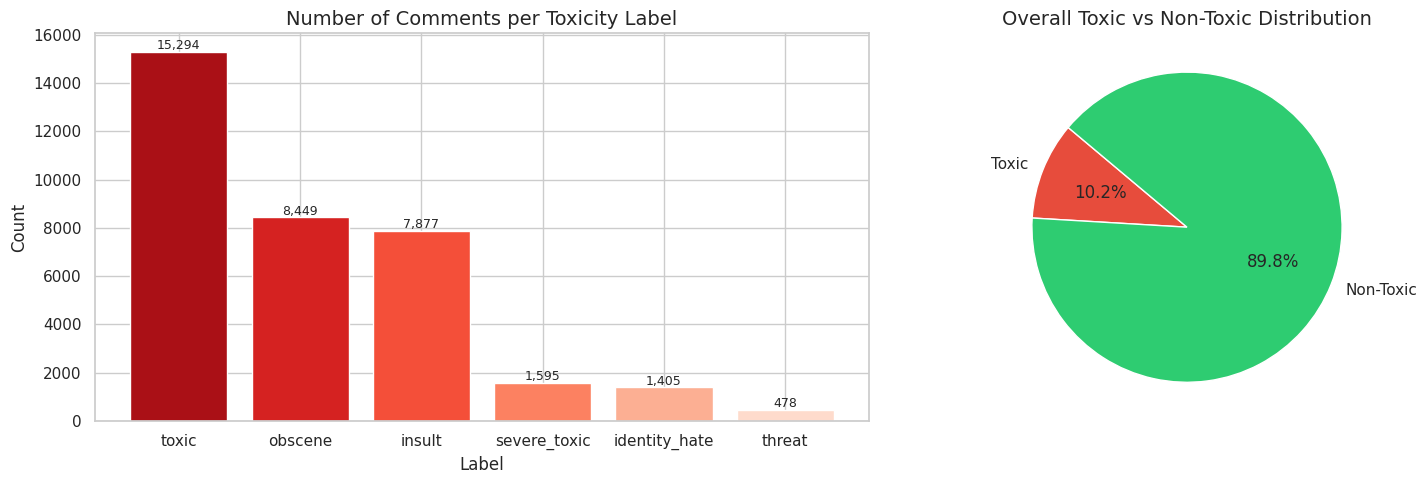

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('Reds_r', len(label_cols)))
axes[0].set_title('Number of Comments per Toxicity Label', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    [train_df['any_toxic'].sum(), (train_df['any_toxic']==0).sum()],
    labels=['Toxic', 'Non-Toxic'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140
)
axes[1].set_title('Overall Toxic vs Non-Toxic Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3 Co-occurrence heatmap

Multi-label Co-occurrence Heatmap a comment can belong to multiple categories at the same time

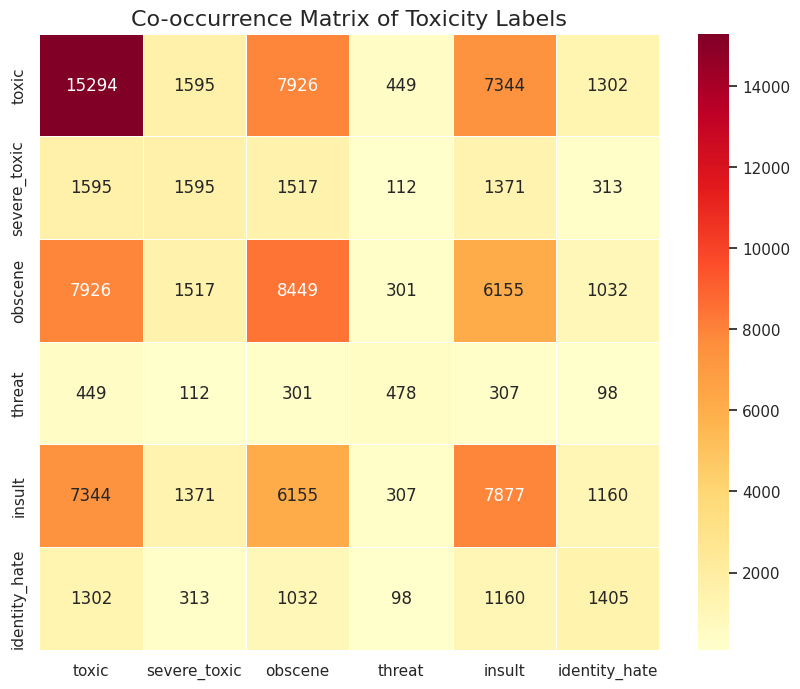

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Toxicity Labels', fontsize=16)
plt.savefig('co_occurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.4 Word clouds

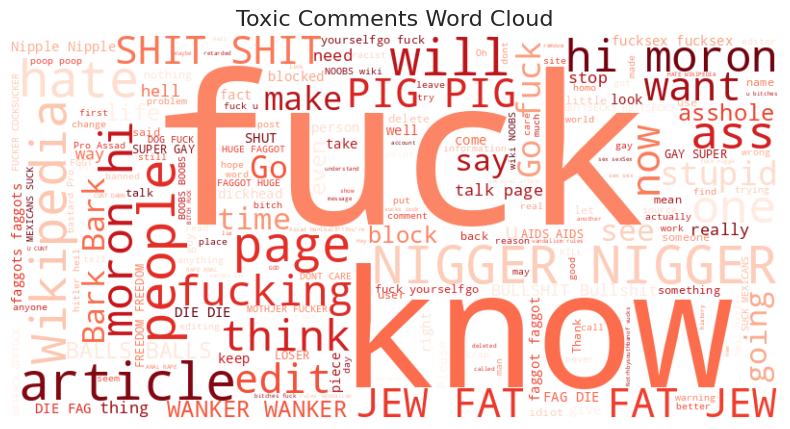

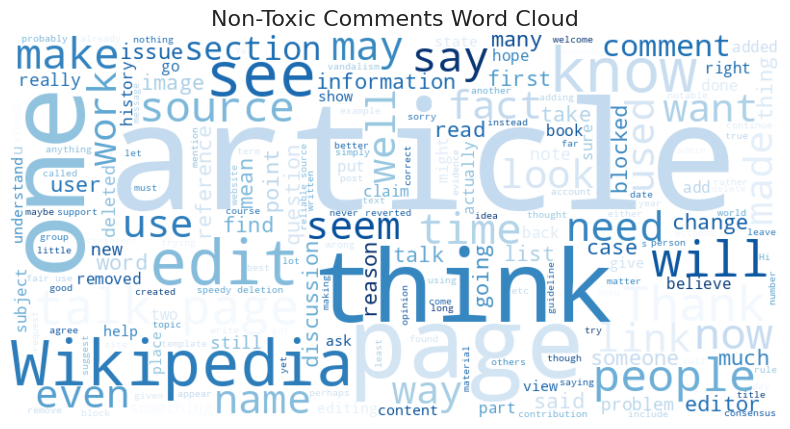

In [13]:
def generate_wordcloud(text_data, title, colormap='Reds'):
  text=' '.join(text_data)
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=colormap,
      max_words=200,
    ).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.show()

generate_wordcloud(train_df[train_df['any_toxic'] == 1]['comment_text'], 'Toxic Comments Word Cloud','Reds')
generate_wordcloud(train_df[train_df['any_toxic'] == 0]['comment_text'], 'Non-Toxic Comments Word Cloud', 'Blues')

## 3.5 Top n-grams

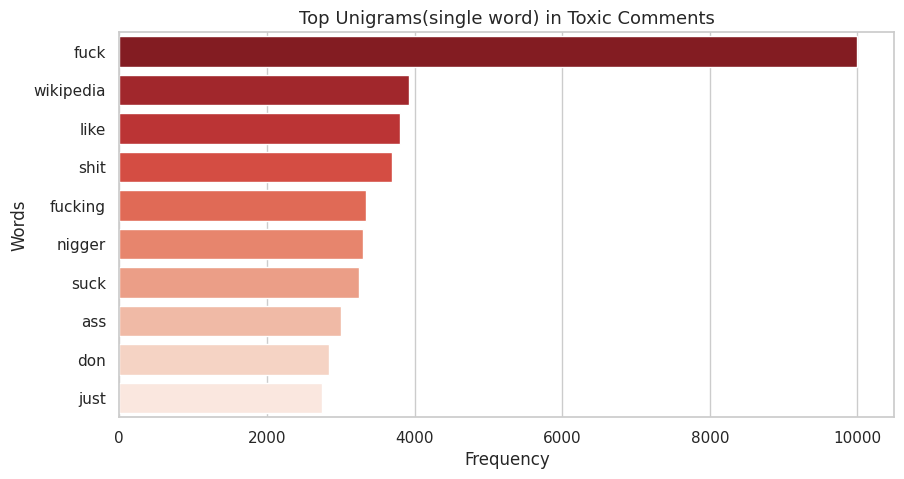

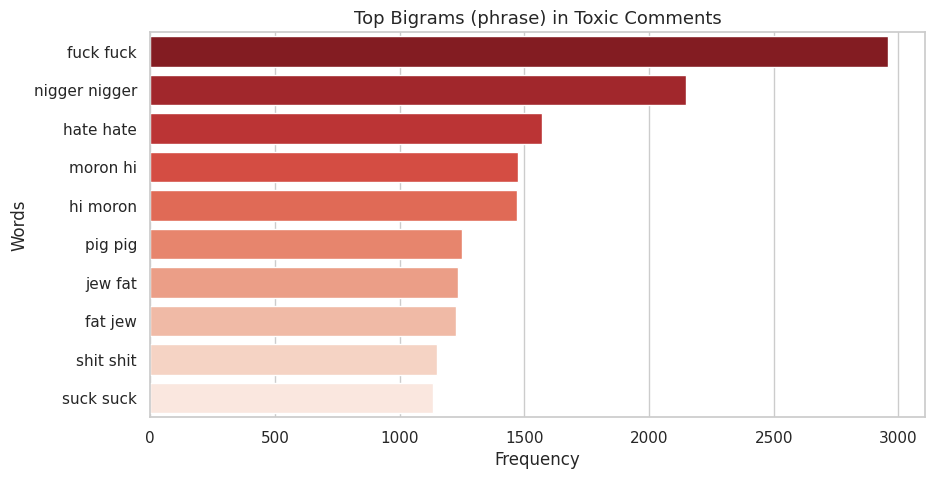

In [14]:
from numpy import vecdot
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams (corpus, title, ngram_range=(1,1), top_n=10):
  vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=1000).fit(corpus)
  bag_of_words = vec.transform(corpus)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  top_n_ngrams = words_freq[:top_n]
  words = [word for word, freq in top_n_ngrams]
  freq = [freq for word, freq in top_n_ngrams]

  plt.figure(figsize=(10, 5))
  sns.barplot(
    x=list(freq),
    y=list(words),
    hue=list(words),
    palette='Reds_r',
    legend=False
  )
  plt.title(title, fontsize=13)
  plt.xlabel('Frequency', fontsize=12)
  plt.ylabel('Words', fontsize=12)
  plt.show()

toxic_comments = train_df[train_df['any_toxic'] == 1]['comment_text'].dropna()

get_top_ngrams(toxic_comments, 'Top Unigrams(single word) in Toxic Comments', ngram_range=(1,1), top_n=10)
get_top_ngrams(toxic_comments, 'Top Bigrams (phrase) in Toxic Comments', ngram_range=(2,2), top_n=10)

# 4. Preprocessing

## 4.1 Basic preprocessing



1.  Lower case



In [15]:
def to_lower(text):
    return text.lower()




2. URL remove



In [16]:
def remove_urls(text):
    import re
    return re.sub(r"http\S+|www\S+", "", text)

3. Mentions remove




In [17]:
def remove_mentions(text):
    import re
    return re.sub(r"@\w+", "", text)

4. Remove Punctuation

In [18]:
def remove_punctuation(text):
    import re
    return re.sub(r"[^a-zA-Z\s]", "", text)

5. Remove extra space

In [19]:
def remove_extra_spaces(text):
    import re
    return re.sub(r"\s+", " ", text).strip()

## 4.2 Advance Preprocessing

1. Emoji to text

In [20]:
!pip install emoji
import emoji

def emoji_to_text(text):
  return emoji.demojize(text, delimiters=(" ", " "))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 18.3 MB/s eta 0:00:00


2. Convert to full forms

In [21]:
def expand_contractions(text):
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "don't": "do not",
        "you're": "you are",
        "it's": "it is",
        "i'm": "i am",
        "won't": "will not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    return text

3. Normalize repetitions\
stuuuuupid → stupid

In [22]:
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

4.Bad Word Normalization \
b!tch = bitch

In [23]:
def normalize_obscene(text):
    text = text.replace("b!tch", "bitch")
    text = text.replace("f*ck", "fuck")
    text = text.replace("a$$", "ass")
    return text

5. Tokenization

In [24]:
def tokenize_text(text):
    return word_tokenize(text)

6. Stopwords

In [25]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [26]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

7. Lemmatize

In [27]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

## 4.3 Final pipelines



1.   Basic Preprocess Function



In [28]:
def basic_preprocess(text):
    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)
    return text



2.  Advanced Preprocess Function



In [29]:
def advanced_preprocess(text, remove_sw=True, lemmatize=True):
    text = emoji_to_text(text)
    text = expand_contractions(text)
    text = normalize_obscene(text)
    text = normalize_repeated_chars(text)

    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize_text(text)

    if remove_sw:
        tokens = remove_stopwords(tokens)

    if lemmatize:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)

# 5. Apply Preprocessing



## 1. Applying Basic Preprocess Function






In [30]:
train_df["raw"] = train_df["comment_text"]
train_df["basic_clean"] = train_df["raw"].apply(basic_preprocess)

Comparison Of Raw and Basic Clean by Basic Preprocessing

In [31]:
pd.set_option('display.max_colwidth', None)
train_df[["raw", "basic_clean"]].sample(5)

,raw,basic_clean
36917,"Roilo Golez\nHi, I see you're having trouble writing the biography of Roilo Golez, it will be wise to re-write his biography in your own words. And by the way please cite your references, we are also on the look out for biased articles. Go over this WP:POV. This is what happened to the author of Vicente Magsaysay's article [2007]. (Talk | contribs)",roilo golez hi i see youre having trouble writing the biography of roilo golez it will be wise to rewrite his biography in your own words and by the way please cite your references we are also on the look out for biased articles go over this wppov this is what happened to the author of vicente magsaysays article talk contribs
131426,"""\n\n Please do not vandalize pages, as you did with this edit to Tiki Barber. If you continue to do so, you will be blocked from editing. """,please do not vandalize pages as you did with this edit to tiki barber if you continue to do so you will be blocked from editing
8528,"Searches of its official website, its council agendas and minutes on its FilePro site and the Drumheller Mail all show no indication that the Town of Drumheller will conduct a census in 2010.",searches of its official website its council agendas and minutes on its filepro site and the drumheller mail all show no indication that the town of drumheller will conduct a census in
99831,"Yeeah! \n\nhttp://en.wikipedia.org/w/index.php?title=In_the_Navy&diff;=129063767&oldid;=128903226\n\nWell that is how it might go but not in my language... for the pie will not be eaten and the navy will still stand! As long as all pie is delivered safely to the Pietropolisilies then everyone will die. The navy is dangerous cause you get to lots of pain inflicting tatoos of pie and the PIE King (a.k.a. the PIE Lord). And as if that wasn't painful engough everyone steps on you with very very very very very very very very ... lots of verys later.. very cold feet and then you have to protect all the pie that is wide open for someone to steal or eat so in the first day you are more than likely to die. But than again if you live you would have engough money to buy 1,000,000 mansions fill with pie and pie swimming pools and maids that made pie ( mmmmm tasty mansion) pie!!",yeeah well that is how it might go but not in my language for the pie will not be eaten and the navy will still stand as long as all pie is delivered safely to the pietropolisilies then everyone will die the navy is dangerous cause you get to lots of pain inflicting tatoos of pie and the pie king aka the pie lord and as if that wasnt painful engough everyone steps on you with very very very very very very very very lots of verys later very cold feet and then you have to protect all the pie that is wide open for someone to steal or eat so in the first day you are more than likely to die but than again if you live you would have engough money to buy mansions fill with pie and pie swimming pools and maids that made pie mmmmm tasty mansion pie
21850,What a ridiculous suggestion. If you don't think certain flags are British then why would it be relevant for the United Kingdom?,what a ridiculous suggestion if you dont think certain flags are british then why would it be relevant for the united kingdom


## 2. Applying Advanced Preprocess Function

In [32]:
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [33]:
train_df["advanced_clean"] = train_df["raw"].apply(advanced_preprocess)

Comparison of Raw and Advanced Clean by Advanced Preprocessing

In [34]:
pd.set_option('display.max_colwidth', None)
train_df[["raw","advanced_clean"]].sample(5)

,raw,advanced_clean
18929,". Finally, the way that long time expert wiki editors are not protect from verbal abuse by vandals is only going to hurt Wikipedia in the long term, by wiki editors that are experts in their field leaving Wikipedia in large numbers. I am seriously considering this",finally way long time expert wiki editor protect verbal abuse vandal going hurt wikipedia long term wiki editor expert field leaving wikipedia large number seriously considering
92965,"Abusive admin.\nWhy are admins so poorly monitored on here? | Have you ever heard of this guy? http://en.wikipedia.org/wiki/User_talk:AntonioMartin Scroll down to the Walter Mercado topic. This Antonio guy is a bigot. Naturally, nobody has talked to him about this. 98.232.181.201",abusive admin admins poorly monitored ever heard guy scroll walter mercado topic antonio guy bigot naturally nobody talked
17853,References \n\nThis page needs to have references to be taken seriously,reference page need reference taken seriously
152143,"""\n\n This article needs to be saved. \nWe use the term in econ classes/seminars at our institution. The term needs to be further clarified here. 'Biflation' refers to """"PRICE"""" inflation and deflation occurring simultaneously in different asset classes, not monetary inflation and deflation occurring simultaneously.""",article need saved use term econ classesseminars institution term need clarified biflation refers price inflation deflation occurring simultaneously different asset class monetary inflation deflation occurring simultaneously
81348,""""""", except for you because you know nothing about music charts and high quality images.\n""",except know nothing music chart high quality image


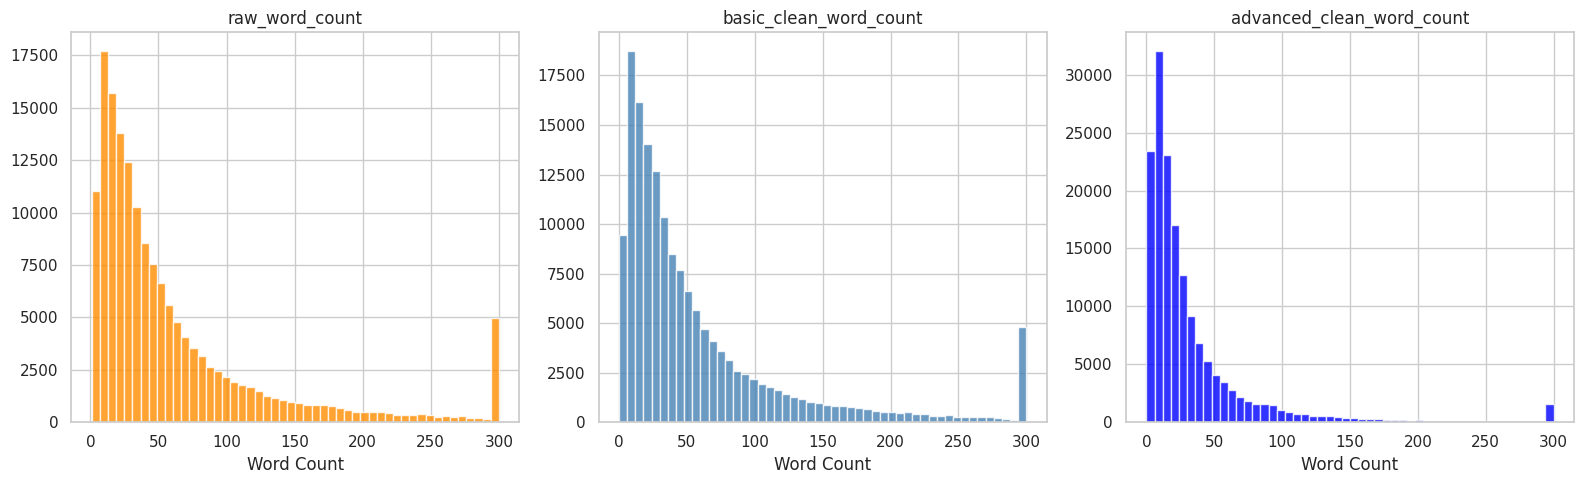

In [35]:
train_df['raw_word_count'] =train_df['comment_text'].str.split().str.len()
train_df['basic_clean_word_count'] =train_df['basic_clean'].str.split().str.len()
train_df['advanced_clean_word_count'] =train_df['advanced_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].hist(train_df['raw_word_count'].clip(upper=300),bins=50,color="darkorange", edgecolor='white',alpha=0.8)
axes[0].set_title('raw_word_count' , fontsize=12)
axes[0].set_xlabel('Word Count')


axes[1].hist(train_df['basic_clean_word_count'].clip(upper=300),bins=50,color="steelblue", edgecolor='white',alpha=0.8)
axes[1].set_title('basic_clean_word_count' , fontsize=12)
axes[1].set_xlabel('Word Count')


axes[2].hist(train_df['advanced_clean_word_count'].clip(upper=300),bins=50,color="blue", edgecolor='white',alpha=0.8)
axes[2].set_title('advanced_clean_word_count' , fontsize=12)
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
print('Raw text stats:')    ; print(train_df['raw_word_count'].describe().round(1))
print('\n basic Cleaned text stats:'); print(train_df['basic_clean_word_count'].describe().round(1))
print('\n advance Cleaned text stats:'); print(train_df['advanced_clean_word_count'].describe().round(1))


Raw text stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: raw_word_count, dtype: float64

 basic Cleaned text stats:
count    159571.0
mean         65.4
std          97.3
min           0.0
25%          16.0
50%          35.0
75%          73.0
max        1403.0
Name: basic_clean_word_count, dtype: float64

 advance Cleaned text stats:
count    159571.0
mean         34.0
std          52.5
min           0.0
25%           8.0
50%          18.0
75%          37.0
max        1250.0
Name: advanced_clean_word_count, dtype: float64


# 6. Train/Validation/Test Split

In [37]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
x = train_df[['raw','basic_clean','advanced_clean']]
y = train_df[label_counts.index]

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df['any_toxic']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=y_temp.max(axis=1)
)

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')


Train : 127,656  |  Val : 15,957  |  Test : 15,958


# 7. Feature Extraction

## 7.1 TF-IDF Features

(for LR and SVM)
use advanced_clean

In [38]:
tfidf = TfidfVectorizer(
    max_features=50000 ,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df =3
)
X_train_tfidf = tfidf.fit_transform(X_train['advanced_clean'])
X_val_tfidf = tfidf.transform(X_val['advanced_clean'])
X_test_tfidf = tfidf.transform(X_test['advanced_clean'])

In [39]:
print('TD_IFD shape train', X_train_tfidf.shape)
print('TD_IFD shape val', X_val_tfidf.shape)
print('TD_IFD shape test', X_test_tfidf.shape)

TD_IFD shape train (127656, 50000)
TD_IFD shape val (15957, 50000)
TD_IFD shape test (15958, 50000)


## 7.2 LSTM Tokenization

In [40]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [41]:
Vocab_size =10000
max_len= 100

lstm_tok = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok.fit_on_texts(X_train['basic_clean'])

def to_padded(texts):
  seqs = lstm_tok.texts_to_sequences(texts)
  return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
X_train_lstm = to_padded(X_train['basic_clean'])
X_val_lstm = to_padded(X_val['basic_clean'])
X_test_lstm = to_padded(X_test['basic_clean'])

## 7.3 BERT Tokenization

In [42]:
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)

In [43]:
Bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def bert_encode(texts, max_len=512):
   enc =bert_tokenizer(
       list(texts),
       max_length=max_len,
       truncation=True,
       padding = 'max_length',
       return_tensors='tf'
   )
   return enc['input_ids'], enc['attention_mask']

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# 8 . Evaluation Utilities

## 1. evaluate()

In [44]:
results ={}
def evaluate(model_name,y_true,y_pred, elapsed_train=None,elapsed_infer=None ):
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro',zero_division=0)
  rec = recall_score(y_true, y_pred, average='macro',zero_division=0)
  f1 = f1_score(y_true, y_pred, average='macro',zero_division=0)

  results[model_name] = {
      'accuracy': round(acc,4),
      'precision': round(prec,4),
      'recall': round(rec,4),
      'f1 (macro)': round(f1,4),
      'train time (s)':round( elapsed_train,1) if elapsed_train else '-',
      'infer time (s)': round(elapsed_infer,1) if elapsed_infer else '-'
  }
  print(f'\n===== {model_name} =====')
  print(f'  accuracy : {acc:.4f}')
  print(f'  precision: {prec:.4f}')
  print(f'  recall   : {rec:.4f}')
  print(f'  f1 Macro : {f1:.4f}')
  if elapsed_train: print(f'  train time: {elapsed_train:.1f}s')
  return results[model_name]

## 2. confusion matrix

In [45]:
def plot_confusion(model_name,y_true, y_pred, lables=label_cols):
   fig, axes = plt.subplots( 2,3, figsize=(15,8))
   for ax, col in zip(axes.flatten(), lables):
       cm = confusion_matrix(y_true[:, lables.index(col)],
                              y_pred[:, lables.index(col)])
       sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues', cbar=False)
       ax.set_title(col, fontsize=11)
       ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
   plt.suptitle(f'Confusion Matrices — {model_name}', fontsize=14)
   plt.tight_layout()
   plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
   plt.show()

print('Evaluation helpers ready.')

Evaluation helpers ready.


# 9. Traditional ML Models

## 9.1 Logistic Regression

Raw Text

In [46]:
tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_raw = tfidf_raw.fit_transform(X_train['raw'])
X_test_tfidf_raw = tfidf_raw.transform(X_test['raw'])

lr_raw = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_raw.fit(X_train_tfidf_raw, y_train)
with open('lr_raw_model.pkl', 'wb') as f:
    pickle.dump(lr_raw, f)
with open('tfidf_raw_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_raw, f)

In [47]:
with open('tfidf_raw_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)
with open('lr_raw_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [48]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')
t0=time.time()
y_pred_raw = lr_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0

Train time: 33.5s


Evaluate the model for raw data

In [49]:
evaluate('TF-IDF + LR (raw)', y_test.values, y_pred_raw, train_t, infer_t)


===== TF-IDF + LR (raw) =====
  accuracy : 0.9204
  precision: 0.8366
  recall   : 0.3936
  f1 Macro : 0.5099
  train time: 33.5s


{'accuracy': 0.9204,
 'precision': 0.8366,
 'recall': 0.3936,
 'f1 (macro)': 0.5099,
 'train time (s)': 33.5,
 'infer time (s)': 0.0}

Confusion plot for the model for raw data

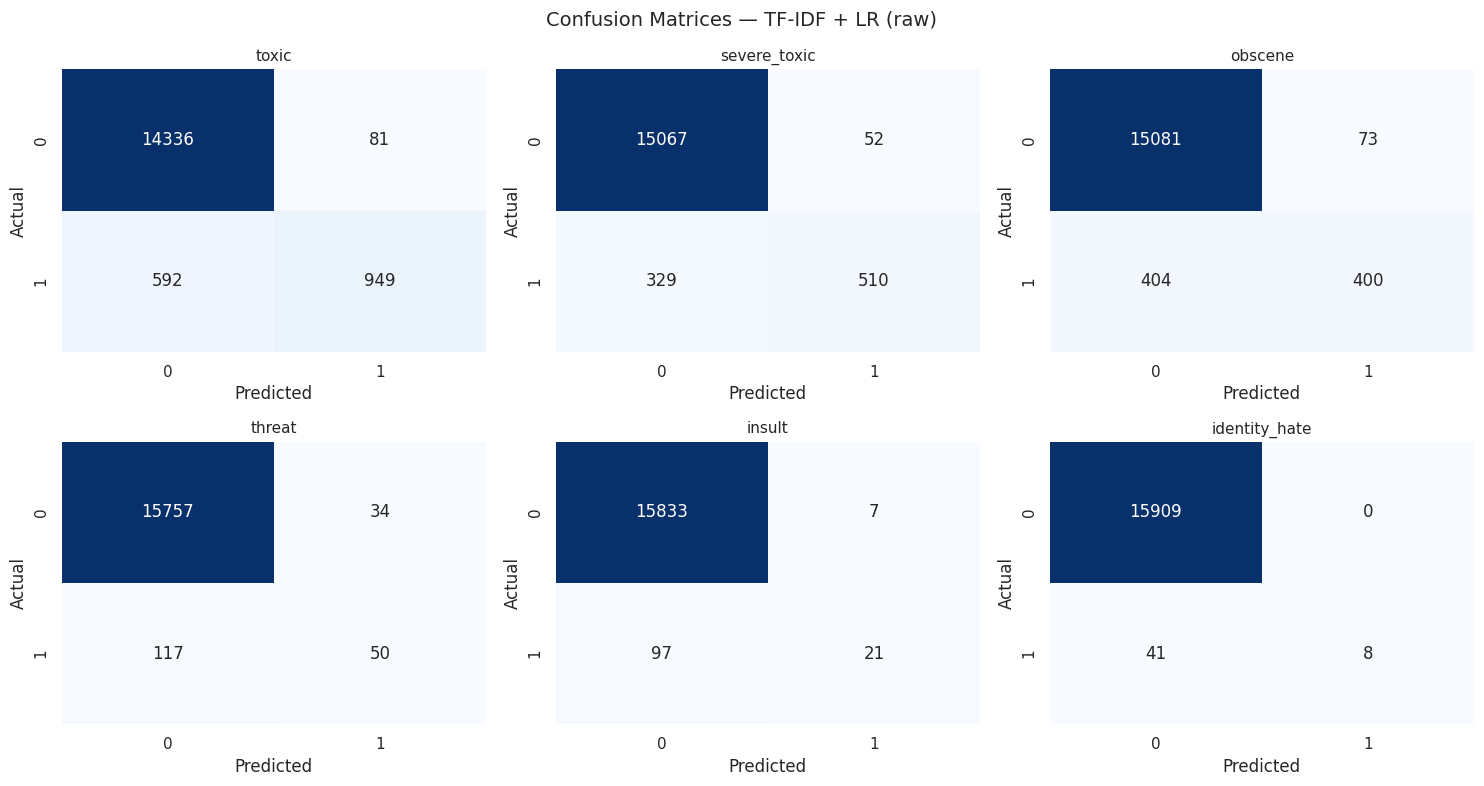

In [50]:
plot_confusion('TF-IDF + LR (raw)', y_test.values, y_pred_raw, label_cols)

Advanced Clean

In [51]:
tfidf_clean = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_clean = tfidf_clean.fit_transform(X_train['advanced_clean'])
X_test_tfidf_clean = tfidf_clean.transform(X_test['advanced_clean'])

lr_clean = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_clean.fit(X_train_tfidf_clean, y_train)
with open('lr_clean_model.pkl', 'wb') as f:
    pickle.dump(lr_clean, f)
with open('tfidf_clean_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_clean, f)

In [52]:
with open('tfidf_clean_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)
with open('lr_clean_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [53]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')
t0=time.time()
y_pred_clean = lr_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 21.0s


Evaluate the model for clean data

In [54]:
evaluate('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, train_t, infer_t)


===== TF-IDF + LR (advanced) =====
  accuracy : 0.9189
  precision: 0.7585
  recall   : 0.3845
  f1 Macro : 0.4852
  train time: 21.0s


{'accuracy': 0.9189,
 'precision': 0.7585,
 'recall': 0.3845,
 'f1 (macro)': 0.4852,
 'train time (s)': 21.0,
 'infer time (s)': 0.0}

Confusion plot for the model for clean data

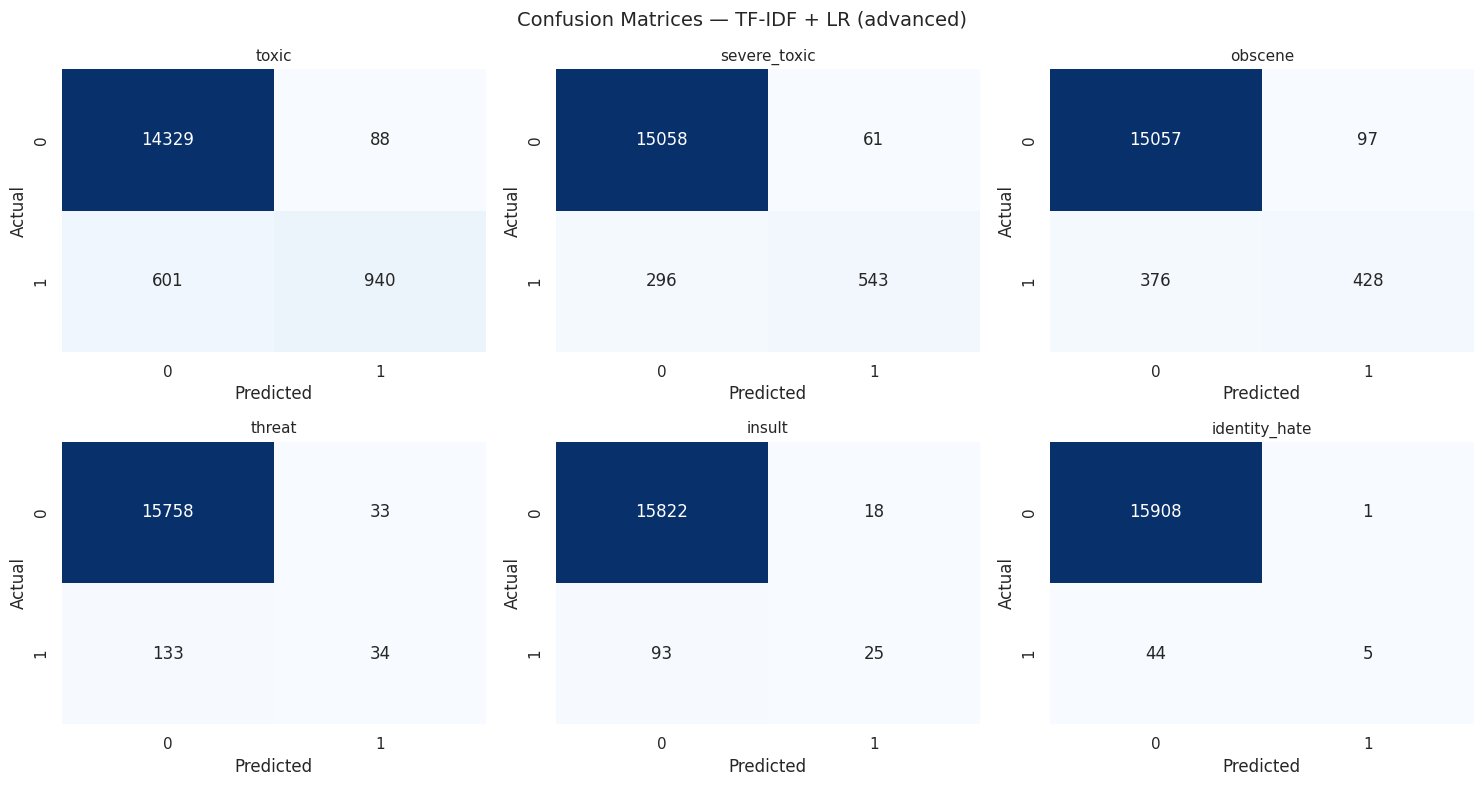

In [55]:
plot_confusion('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, label_cols)

## 9.2 SVM

Raw Text

In [56]:
svm_raw = OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_raw.fit(X_train_tfidf_raw, y_train)
with open('svm_raw_model.pkl', 'wb') as f:
    pickle.dump(svm_raw, f)

In [57]:
with open('svm_raw_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [58]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')
t0=time.time()
y_pred_svm_raw = svm_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0

Train time: 28.5s


Evaluate the model for raw data

In [59]:
evaluate('TF-IDF + SVM (raw)', y_test.values, y_pred_svm_raw, train_t, infer_t)


===== TF-IDF + SVM (raw) =====
  accuracy : 0.9209
  precision: 0.7476
  recall   : 0.5065
  f1 Macro : 0.5944
  train time: 28.5s


{'accuracy': 0.9209,
 'precision': 0.7476,
 'recall': 0.5065,
 'f1 (macro)': 0.5944,
 'train time (s)': 28.5,
 'infer time (s)': 0.1}

Confusion plot for the model for raw data

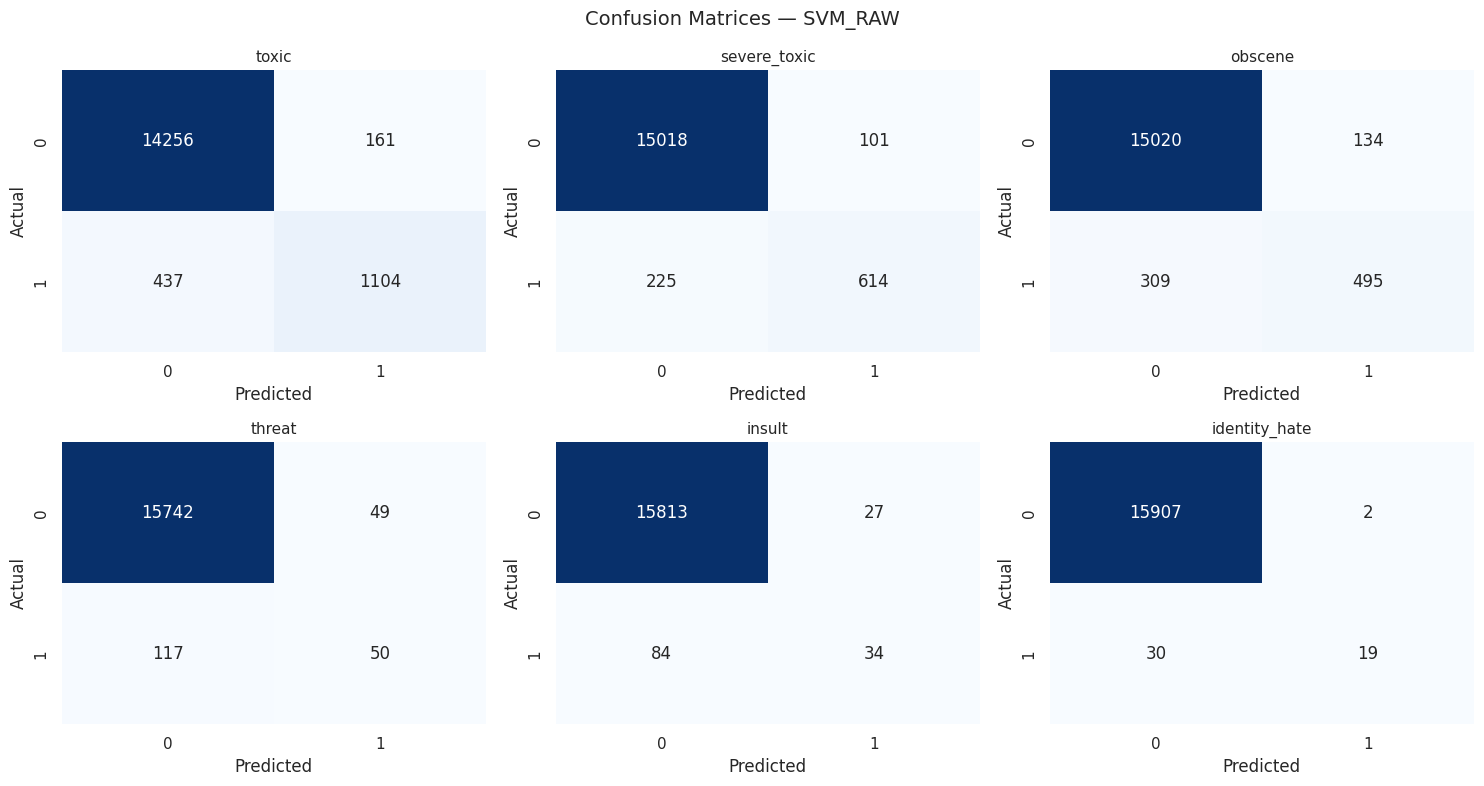

In [60]:
plot_confusion('SVM_RAW',y_test.values,y_pred_svm_raw,label_cols)

Advanced Clean

In [61]:
svm_clean= OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_clean.fit(X_train_tfidf_clean, y_train)
with open('svm_clean_model.pkl', 'wb') as f:
    pickle.dump(svm_clean, f)

In [62]:
with open('svm_clean_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [63]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_clean = svm_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 14.5s



Evaluate the model for clean data

In [64]:
evaluate('TF-IDF + SVM (advanced)', y_test.values, y_pred_svm_clean, train_t, infer_t)


===== TF-IDF + SVM (advanced) =====
  accuracy : 0.9187
  precision: 0.7193
  recall   : 0.4957
  f1 Macro : 0.5780
  train time: 14.5s


{'accuracy': 0.9187,
 'precision': 0.7193,
 'recall': 0.4957,
 'f1 (macro)': 0.578,
 'train time (s)': 14.5,
 'infer time (s)': 0.0}

Confusion plot for the model for clean data

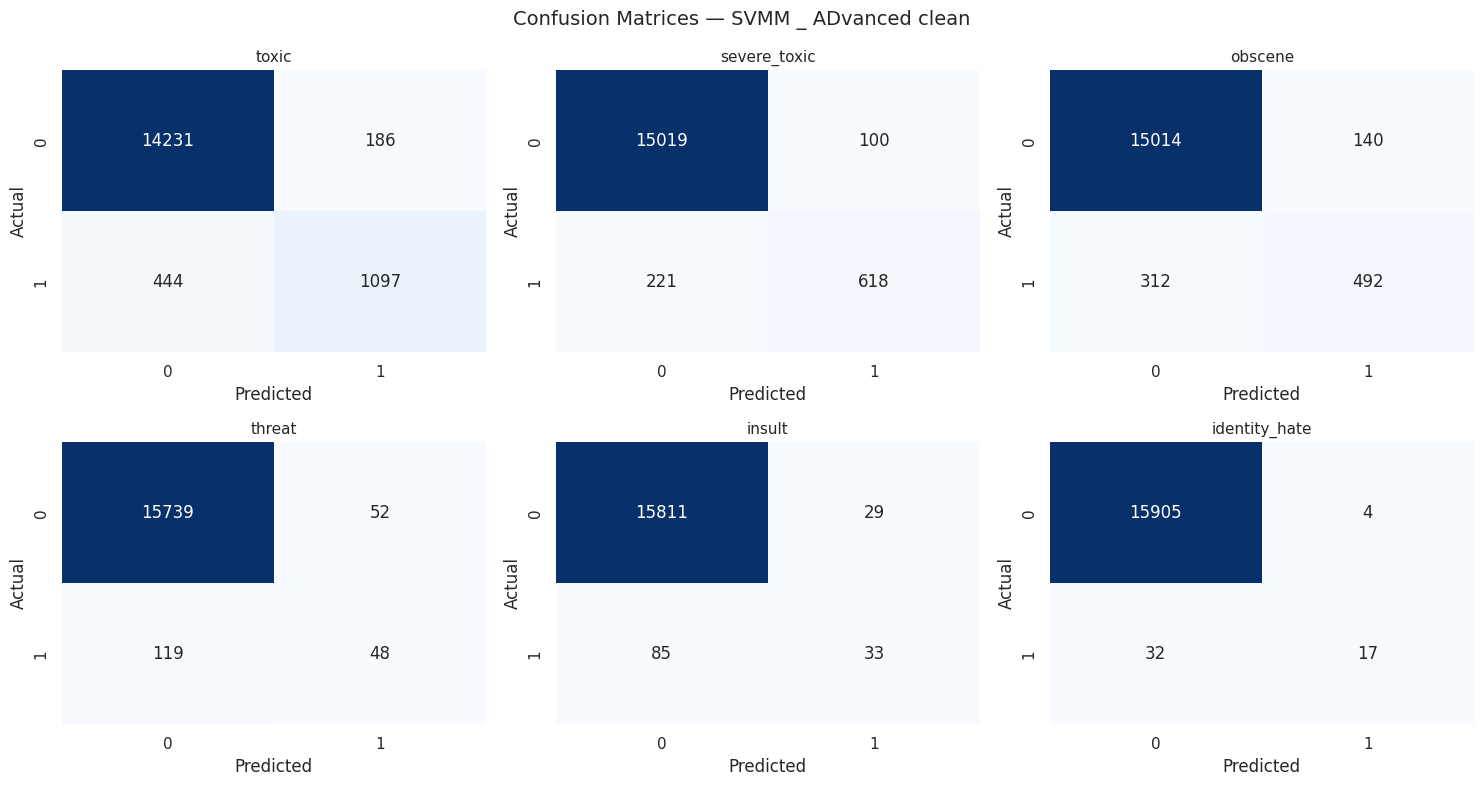

In [65]:
plot_confusion("SVMM _ ADvanced clean", y_test.values, y_pred_svm_clean, label_cols)

# 10. Deep Learning Model

## 10.1 BiLSTM — Basic Clean

Building the model

In [66]:
EMBED_DIM = 128
NUM_LABELS = len(label_cols)

def build_bilstm(Vocab_size, max_len, num_labels):
    inp  = Input(shape=(max_len,))
    x    = Embedding(Vocab_size, EMBED_DIM)(inp)
    x    = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2))(x)
    x    = GlobalMaxPooling1D()(x)
    x    = Dense(128, activation='relu')(x)
    x    = Dropout(0.3)(x)
    out  = Dense(num_labels, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model
lstm_model = build_bilstm(Vocab_size , max_len, NUM_LABELS)
lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,396,102 (5.33 MB)

 Trainable params: 1,396,102 (5.33 MB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [67]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Basic clean

In [ ]:
callbacks =[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)
            ]
t0=time.time()
history = lstm_model.fit(
    X_train_lstm, y_train.values,
    validation_data=(X_val_lstm, y_val.values),
    epochs=10,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)
lstm_model.save("bilstm_model.h5")

Epoch 1/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7480 - loss: 0.1255

In [ ]:

loaded_lstm = load_model("bilstm_model.h5")

In [ ]:
train_t = time.time() - t0

print(f'Train time: {train_t:.1f}s')
t0 = time.time()
y_pred_lstm = (lstm_model.predict(X_test_lstm) > 0.5).astype(int)
lstm_infer_t = time.time() - t0

In [ ]:
evaluate('LSTM — Basic Clean', y_test.values, y_pred_lstm,
         train_t, lstm_infer_t)

In [ ]:
plot_confusion('LSTM — Basic Clean', y_test.values, y_pred_lstm,label_cols)

## Raw DATA

In [ ]:
lstm_tok_raw = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok_raw.fit_on_texts(X_train['raw'])

def to_padded_raw(texts):
    seqs = lstm_tok_raw.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen= max_len ,padding='post', truncating='post')

X_train_lstm_raw = to_padded_raw(X_train['raw'])
X_val_lstm_raw   = to_padded_raw(X_val['raw'])
X_test_lstm_raw  = to_padded_raw(X_test['raw'])

lstm_raw_model = build_bilstm(Vocab_size, max_len, NUM_LABELS)

t0 = time.time()
lstm_raw_model.fit(
    X_train_lstm_raw, y_train.values,
    validation_data=(X_val_lstm_raw, y_val.values),
    epochs=10, batch_size=256,
    callbacks=callbacks, verbose=1
)
lstm_model.save("lstm_raw_model.h5")

In [ ]:
loaded_lstm = load_model("lstm_raw_model.h5")

In [ ]:
lstm_raw_train_time = time.time() - t0

t0 = time.time()
y_pred_lstm_raw = (lstm_raw_model.predict(X_test_lstm_raw) > 0.5).astype(int)
lstm_raw_infer = time.time() - t0

In [ ]:
evaluate('LSTM — Raw', y_test.values, y_pred_lstm_raw, lstm_raw_train_time, lstm_raw_infer)

In [ ]:
plot_confusion('LSTM — RAW', y_test.values, y_pred_lstm_raw,label_cols)

Plot training curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM — Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('LSTM — Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 11. Transformer Model

##  BERT Fine-tuning

11.1 dataset class

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Dataset
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = list(texts)
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.float)
        }

In [ ]:
# Hyperparameters
BERT_BATCH = 32
BERT_EPOCHS = 1
BERT_MAX_LEN = 48

# Create datasets
train_ds = ToxicDataset(X_train['raw'].tolist(), y_train.values, Bert_tokenizer, BERT_MAX_LEN)
val_ds   = ToxicDataset(X_val['raw'].tolist(), y_val.values, Bert_tokenizer, BERT_MAX_LEN)
test_ds  = ToxicDataset(X_test['raw'].tolist(), y_test.values, Bert_tokenizer, BERT_MAX_LEN)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BERT_BATCH, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BERT_BATCH)
test_loader  = DataLoader(test_ds, batch_size=BERT_BATCH)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


11.2 Load the model

In [ ]:
bert_model = BertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_LABELS,
    problem_type='multi_label_classification'
).to(DEVICE)


In [ ]:
optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

total_steps = len(train_loader) * BERT_EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

criterion = torch.nn.BCEWithLogitsLoss()

print("BERT model ready.")

11.3 Training

In [ ]:
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()

    total_loss = 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(train):

        for batch in loader:

            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(outputs.logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0
                )

                optimizer.step()
                scheduler.step()

            total_loss += loss.item()

            preds = (
                torch.sigmoid(outputs.logits) > 0.5
            ).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        np.vstack(all_preds),
        np.vstack(all_labels)
    )

11.3 training loop

In [ ]:
best_val_loss = float('inf')

bert_train_losses = []
bert_val_losses = []

for epoch in range(BERT_EPOCHS):

    start = time.time()

    train_loss, _, _ = run_epoch(
        bert_model,
        train_loader,
        train=True
    )

    val_loss, val_preds, val_labels = run_epoch(
        bert_model,
        val_loader,
        train=False
    )

    bert_train_losses.append(train_loss)
    bert_val_losses.append(val_loss)

    val_f1 = f1_score(
        val_labels,
        val_preds,
        average='macro',
        zero_division=0
    )

    elapsed = time.time() - start

    print(
        f'Epoch {epoch+1}/{BERT_EPOCHS} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Val F1: {val_f1:.4f} | '
        f'Time: {elapsed:.0f}s'
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            bert_model.state_dict(),
            'best_bert.pt'
        )

11.4 evaluation

In [ ]:
evaluate('BERT — Raw', y_true_bert, y_pred_bert, elapsed, bert_infer_t)

In [ ]:
plot_confusion('BERT — Raw', y_true_bert, y_pred_bert)

# 12. Comparative Analysis


## 12.1 performance comparison

In [ ]:
metric_cols = ['accuracy', 'precision', 'recall', 'f1 (macro)']

results_df = pd.DataFrame.from_dict(results, orient='index').reset_index().rename(columns={'index': 'Model'})
plot_df = results_df[['Model'] + metric_cols].copy()
plot_df[metric_cols] = plot_df[metric_cols].astype(float)

plot_melted = plot_df.melt(id_vars='Model', value_vars=metric_cols,
                           var_name='Metric', value_name='Score')

display_name_map = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1 (macro)': 'F1 (macro)'
}
plot_melted['Metric'] = plot_melted['Metric'].map(display_name_map)


plt.figure(figsize=(14, 6))
sns.barplot(data=plot_melted, x='Metric', y='Score', hue='Model',
            palette='Set2')
plt.title('Model Performance Comparison', fontsize=14)
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12.2 preprocessing impact

In [ ]:
raw_models = [m for m in results if 'raw' in m.lower()]

clean_models = [
    m for m in results
    if 'clean' in m.lower() or 'advanced' in m.lower()
]

preprocess_rows = []
for arch in ['LR','SVM','LSTM']:
    raw_key   = next((m for m in raw_models   if arch.lower() in m.lower()), None)
    clean_key = next((m for m in clean_models if arch.lower() in m.lower()), None)
    if raw_key and clean_key:
        preprocess_rows.append({
            'Architecture': arch,
            'F1 Raw'      : results[raw_key]['f1 (macro)'],
            'F1 Cleaned'  : results[clean_key]['f1 (macro)']
        })

preproc_df = pd.DataFrame(preprocess_rows)

x = np.arange(len(preproc_df))
w = 0.35
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - w/2, preproc_df['F1 Raw'],     w, label='Raw Text',     color='#e74c3c')
ax.bar(x + w/2, preproc_df['F1 Cleaned'], w, label='Cleaned Text', color='#2ecc71')
ax.set_xticks(x); ax.set_xticklabels(preproc_df['Architecture'])
ax.set_title('Preprocessing Impact on F1 Score', fontsize=13)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig('preprocessing_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print(preproc_df)

## 12.3 training time

In [ ]:
time_df = results_df[['Model', 'train time (s)']].copy()
time_df = time_df[time_df['train time (s)'] != '-']
time_df['train time (s)'] = time_df['train time (s)'].astype(float)

plt.figure(figsize=(12, 5))
sns.barplot(data=time_df, x='Model', y='train time (s)', palette='Blues_d')
plt.title('Training Time Comparison (seconds)', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 12.4 error analysis

In [ ]:
test_texts = X_test['raw'].values

wrong_mask = (y_true_bert != y_pred_bert).any(axis=1)
wrong_idx  = np.where(wrong_mask)[0]

print(f'Misclassified samples (BERT): {wrong_mask.sum()} / {len(y_true_bert)}')

error_df = pd.DataFrame({
    'text'       : [test_texts[i][:200] for i in wrong_idx[:20]],
    'true_labels': [dict(zip(label_cols, y_true_bert[i])) for i in wrong_idx[:20]],
    'pred_labels': [dict(zip(label_cols, y_pred_bert[i])) for i in wrong_idx[:20]]
})

pd.set_option('display.max_colwidth', 120)
error_df.head(10)

#14. Final Discussion


In [ ]:
print('\n' + '='*70)
print('FINAL RESULTS SUMMARY')
print('='*70)
print(results_df.to_string(index=False))
print('='*70)

best_model = results_df.iloc[0]
print(f'\n Best model : {best_model["Model"]}')
print(f' F1 (macro) : {best_model["f1 (macro)"]}')
print(f' Accuracy   : {best_model["accuracy"]}')